Joyce Wang

11/17/2025

Referred to: 
- https://nbisweden.github.io/workshop-scRNAseq/labs/scanpy/scanpy_05_dge.html#meta-dge_gsa
- GSEAPY documentation: https://gseapy.readthedocs.io/en/latest/gseapy_example.html#Assign-prerank()-with


# Gene Set Enrichment Analysis with GSEAPY: Intro

*"We can perform gene set enrichment analysis (GSEA), which scores ranked genes list (usually based on fold changes) and computes permutation test to check if a particular gene set is more present in the Up-regulated genes, among the DOWN_regulated genes or not differentially regulated..."*

In [37]:
# pip install gseapy

In [13]:
# Core libraries
import hisepy
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# Load in data

In [2]:
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
#creating a list
adata_list = []

#looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [10]:
# using anndata to concatenate: code chunk from Scanpy tutorial

# combine multiple anndata objects and adds a "sample" column telling you which dataset each cell came from; aka, which DRUG NAME each cell was treated with!
adata = ad.concat(adata_list, label="sample")

# make sure all observations are unique
adata.obs_names_make_unique()

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [5]:
# len(adata_list) for how many files are in the list: 18, for 8 drugs with 2 formulas each and 2 controls
print(f"Length of adata_list is {len(adata_list)}")

adata

Length of adata_list is 18


AnnData object with n_obs × n_vars = 450000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample'
    obsm: 'X_pca', 'X_umap'

**The data contains 25,000 cells per sample, 18 samples (for 8 drugs with 2 formulas each and 2 controls), 450,000 observations (total cells), and 1,916 measured genes.**

# Normalization

In [14]:
# rescale each cell to a specific library size
sc.pp.normalize_total(adata, target_sum = 1e4)

# apply log-transform to the data
adata.layers["log_transformed"] = np.log1p(adata.X)

# DEGs, pasted from what Sean was trying

In [22]:
# making a dictionary of subsetted data where the key is the cell type and the value is the anndata object
subsets_cells = {}

for cell_type in adata.obs['AIFI_L2'].unique():
    # print(f'current cell type is {cell_type}')
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "drug_name",
        reference = "DMSO Control",
        method = "wilcoxon",
        layer = "log_transformed"
    )
    subsets_cells[cell_type] = cell_type_subset

# print(subsets_cells)

# figure out grabbing the data frames from these -- adata.to_df()

# get_rank

ValueError: Could not calculate statistics for groups Gefitinib (ZD1839), Baricitinib (LY3009104, INCB028050), Ruxolitinib phosphate, Afatinib dimaleate, Erlotinib, Baricitinib phosphate, Erlotinib Hydrochloride since they only contain one sample.

CD4 Central Memory
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


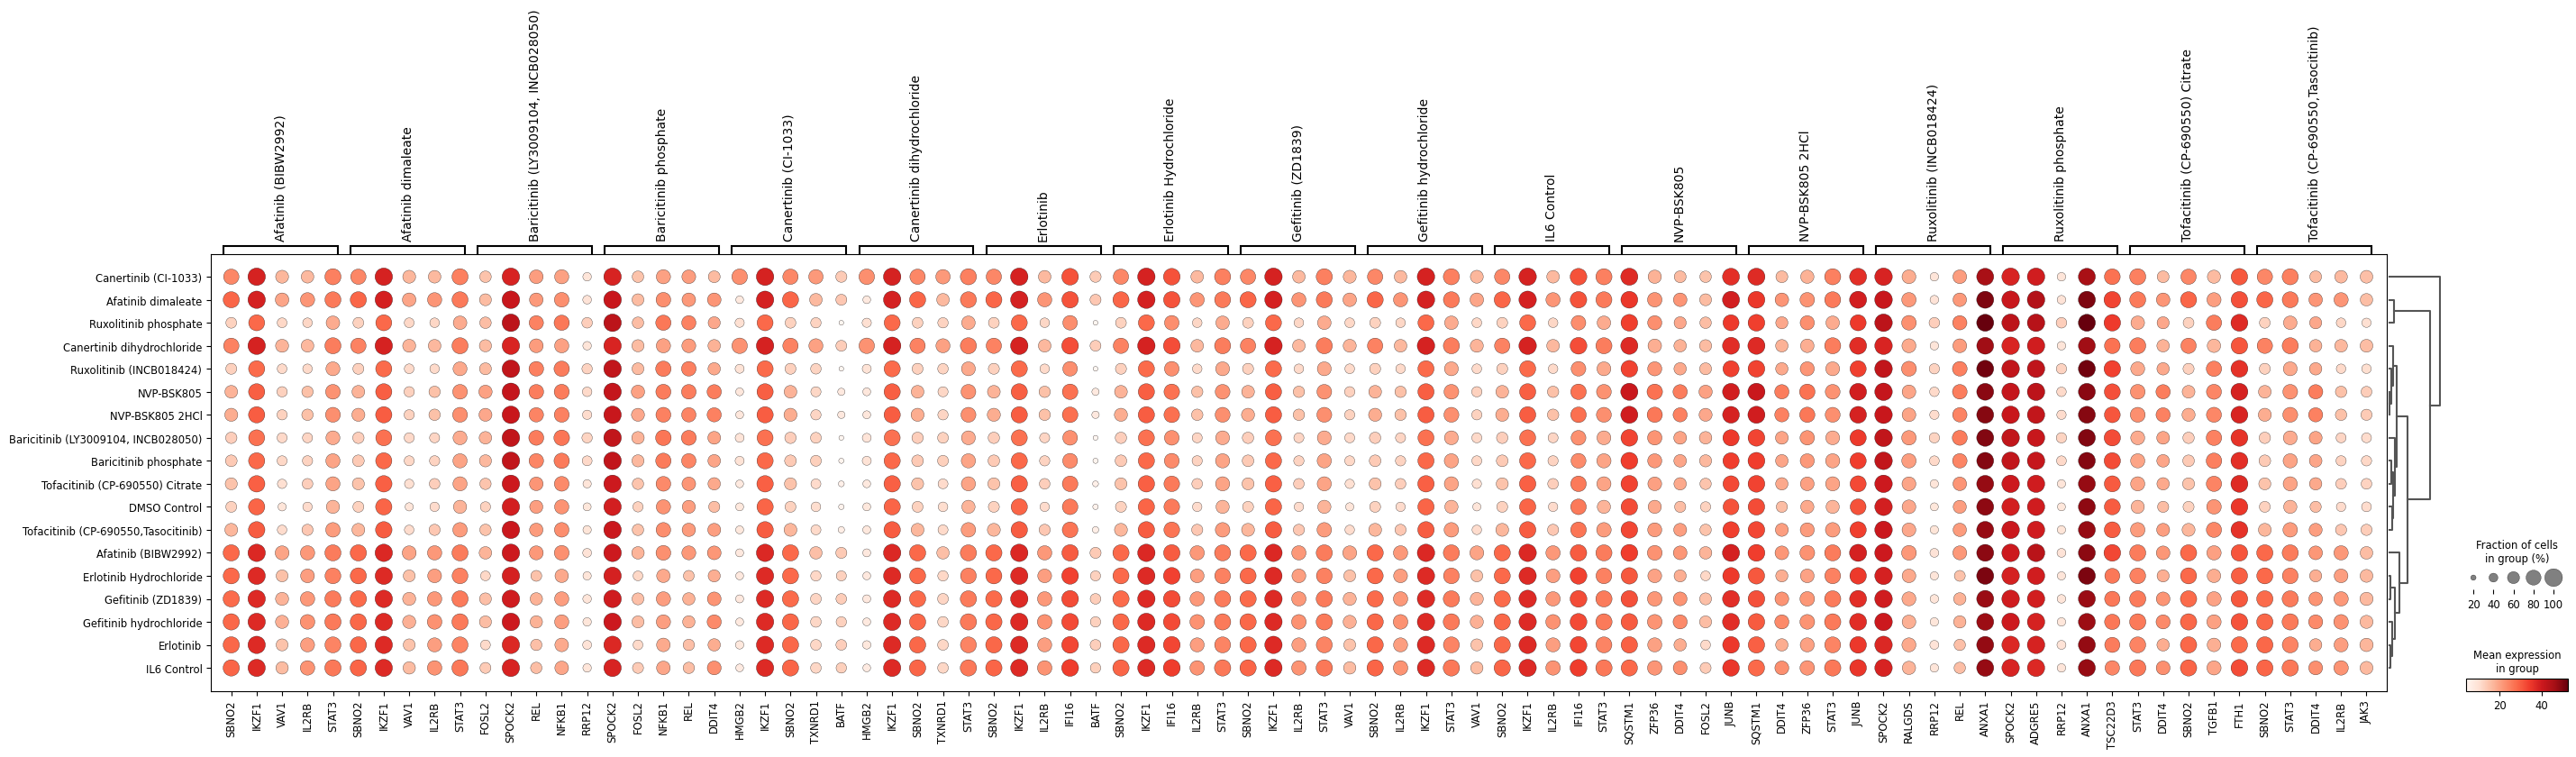

CD8 Naive
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


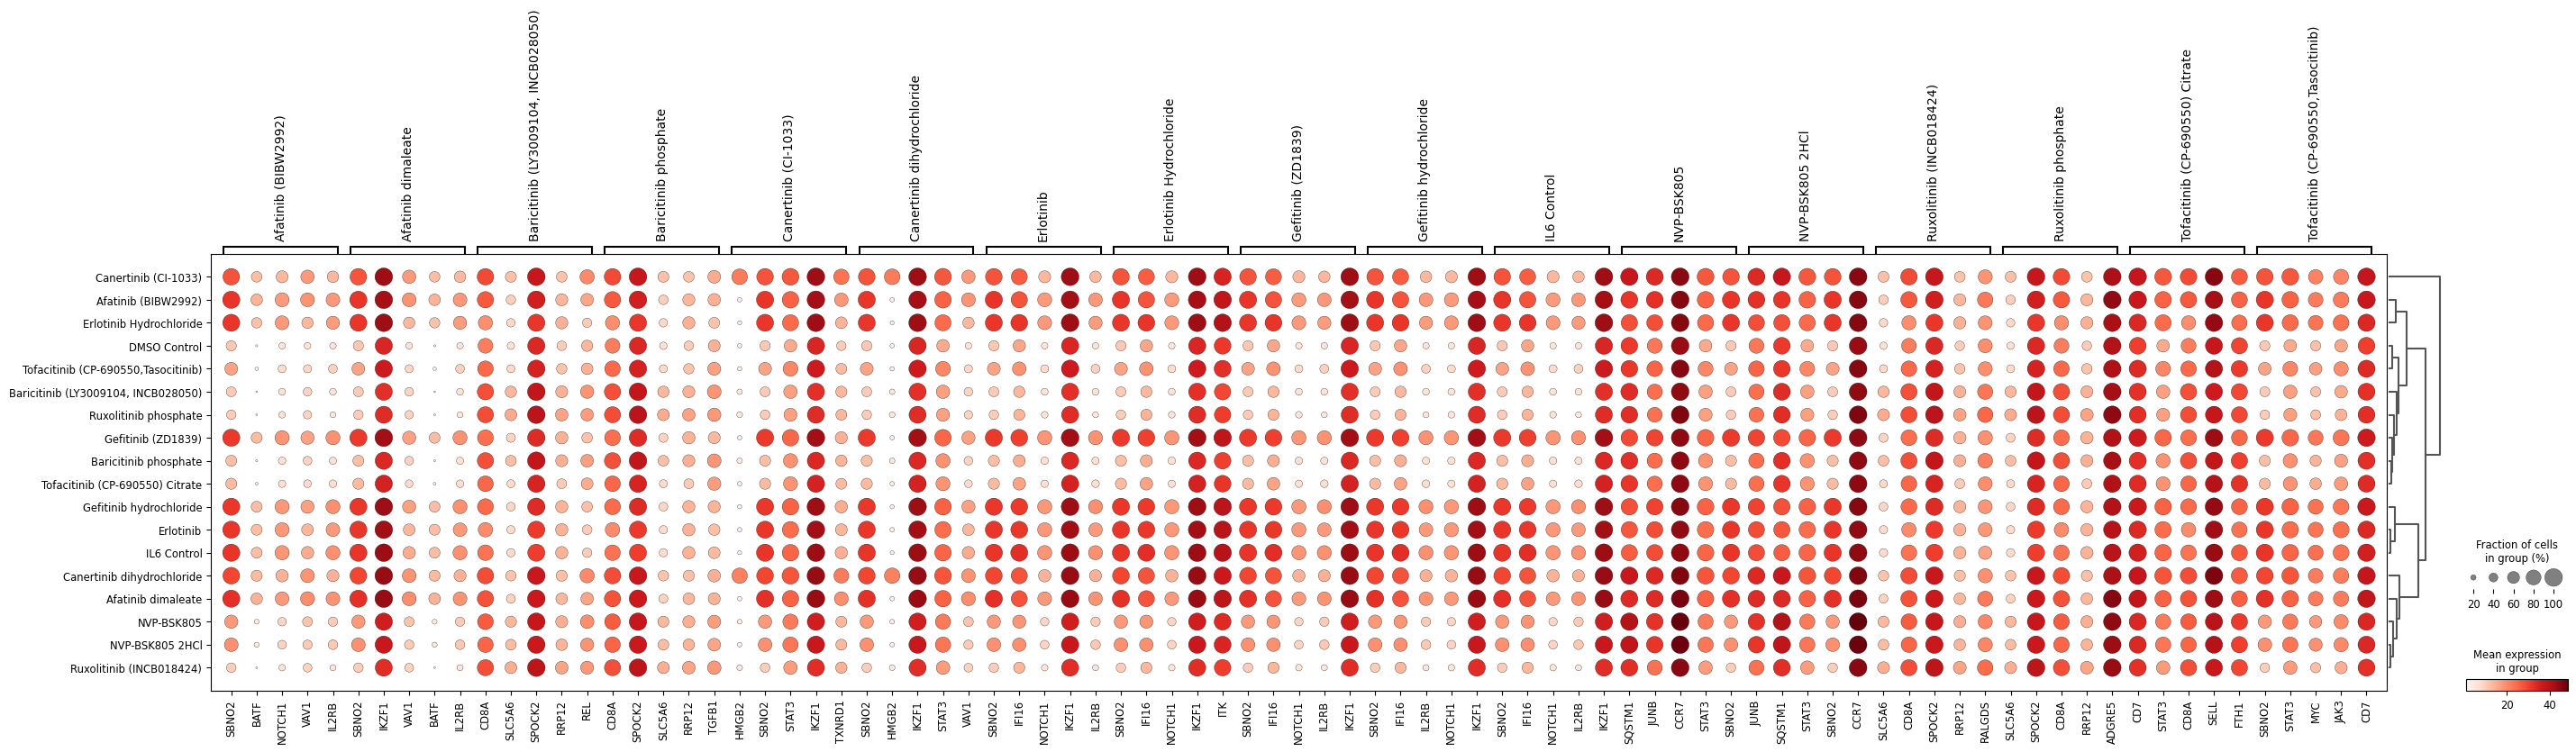

CD8 Effector Memory
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


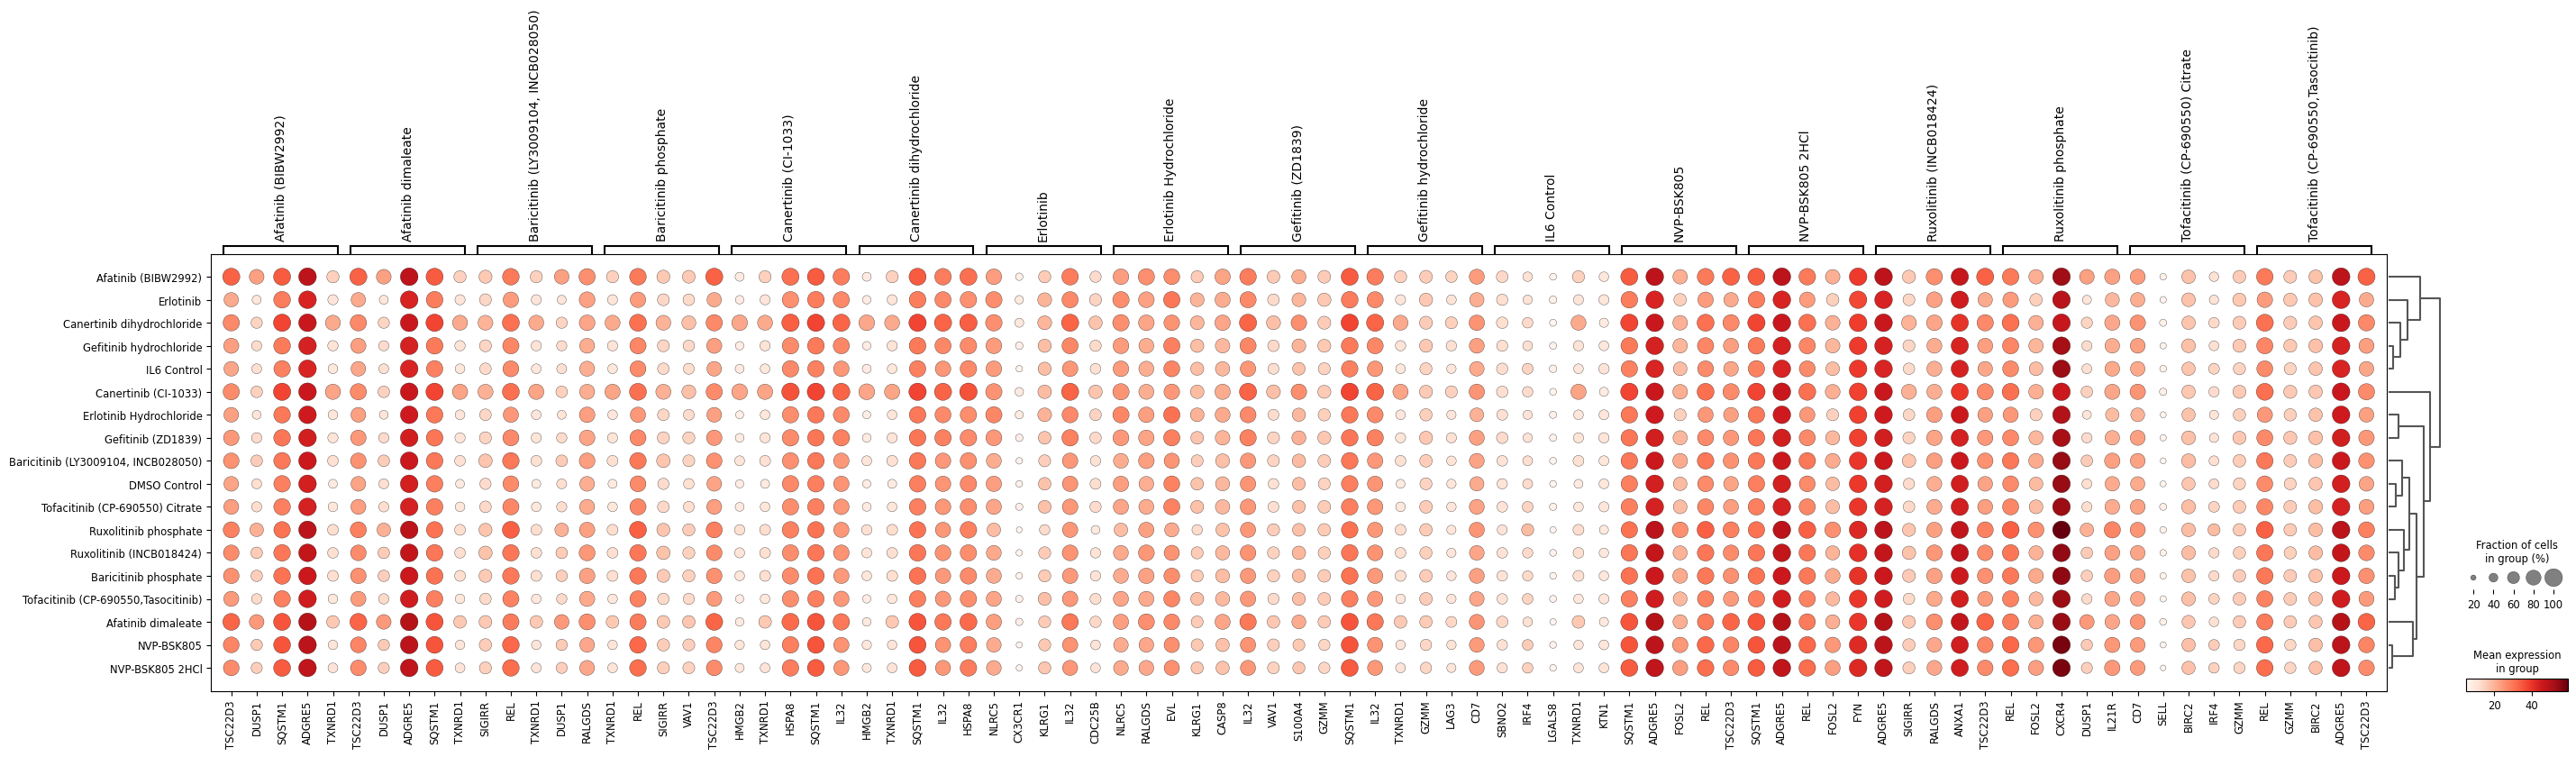

CD8 Central Memory
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


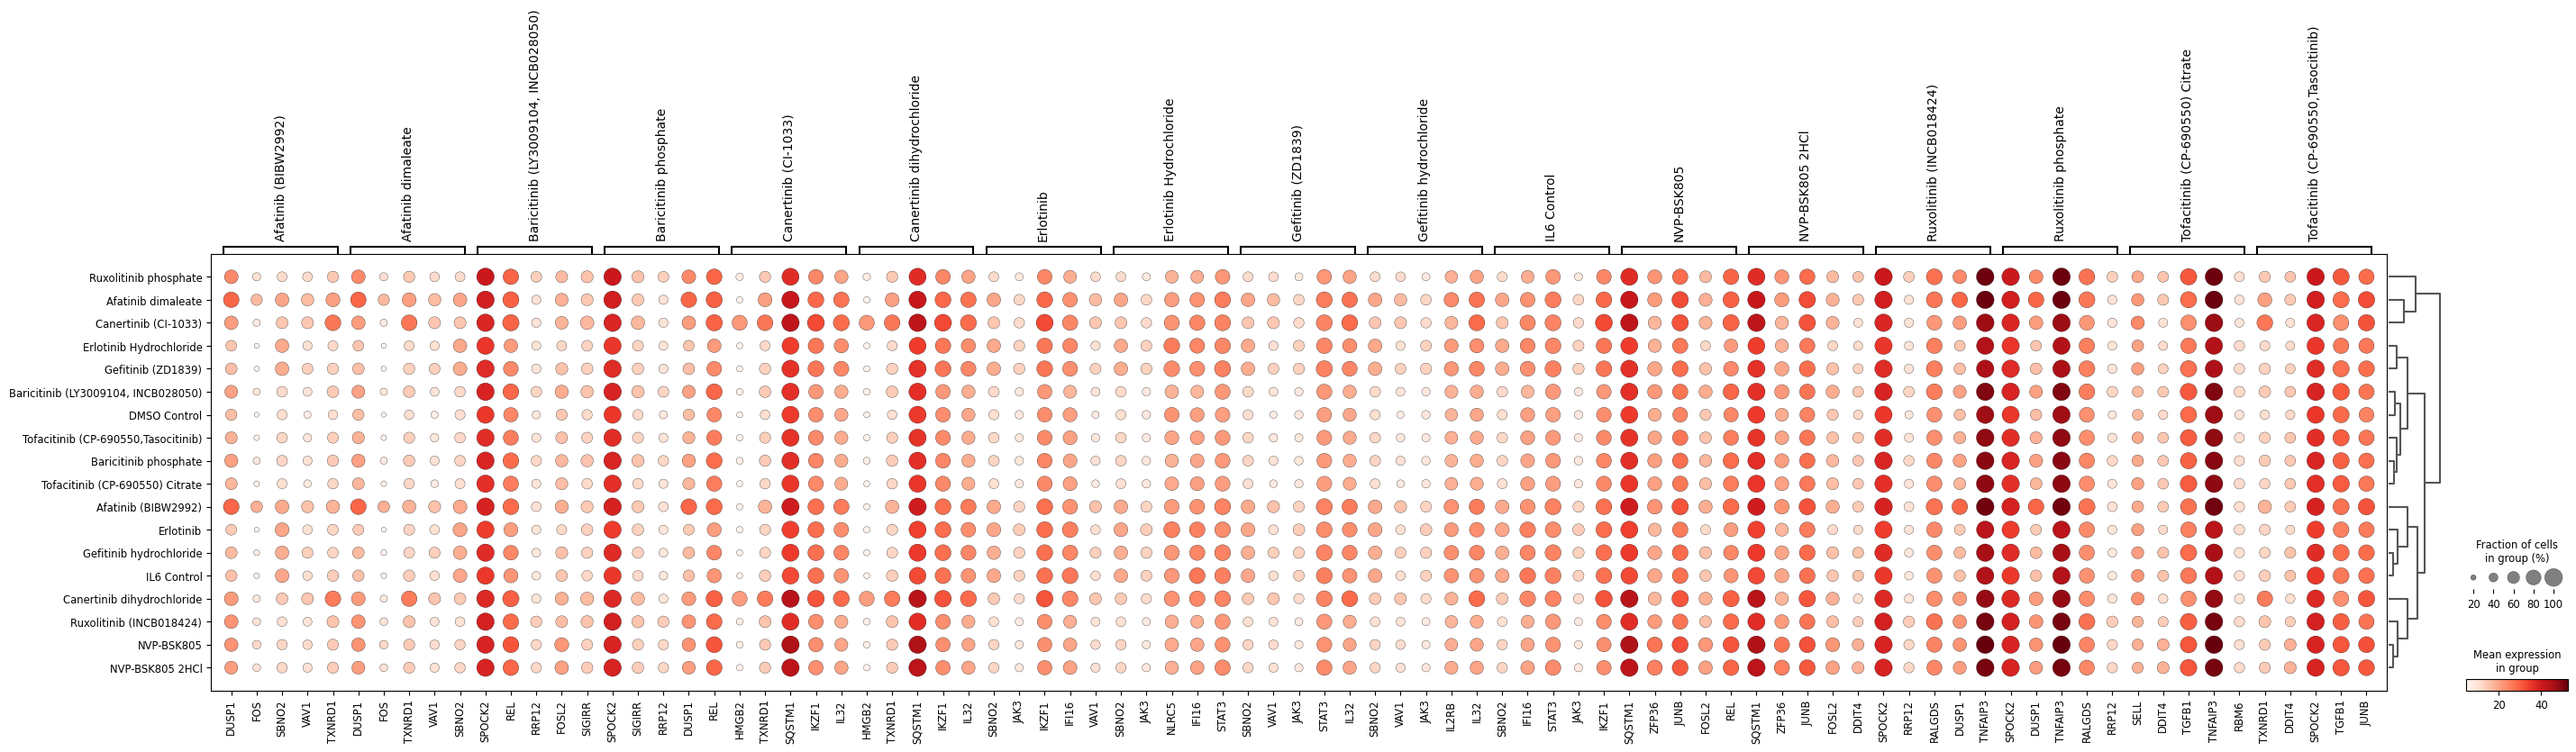

CD4 Naive
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


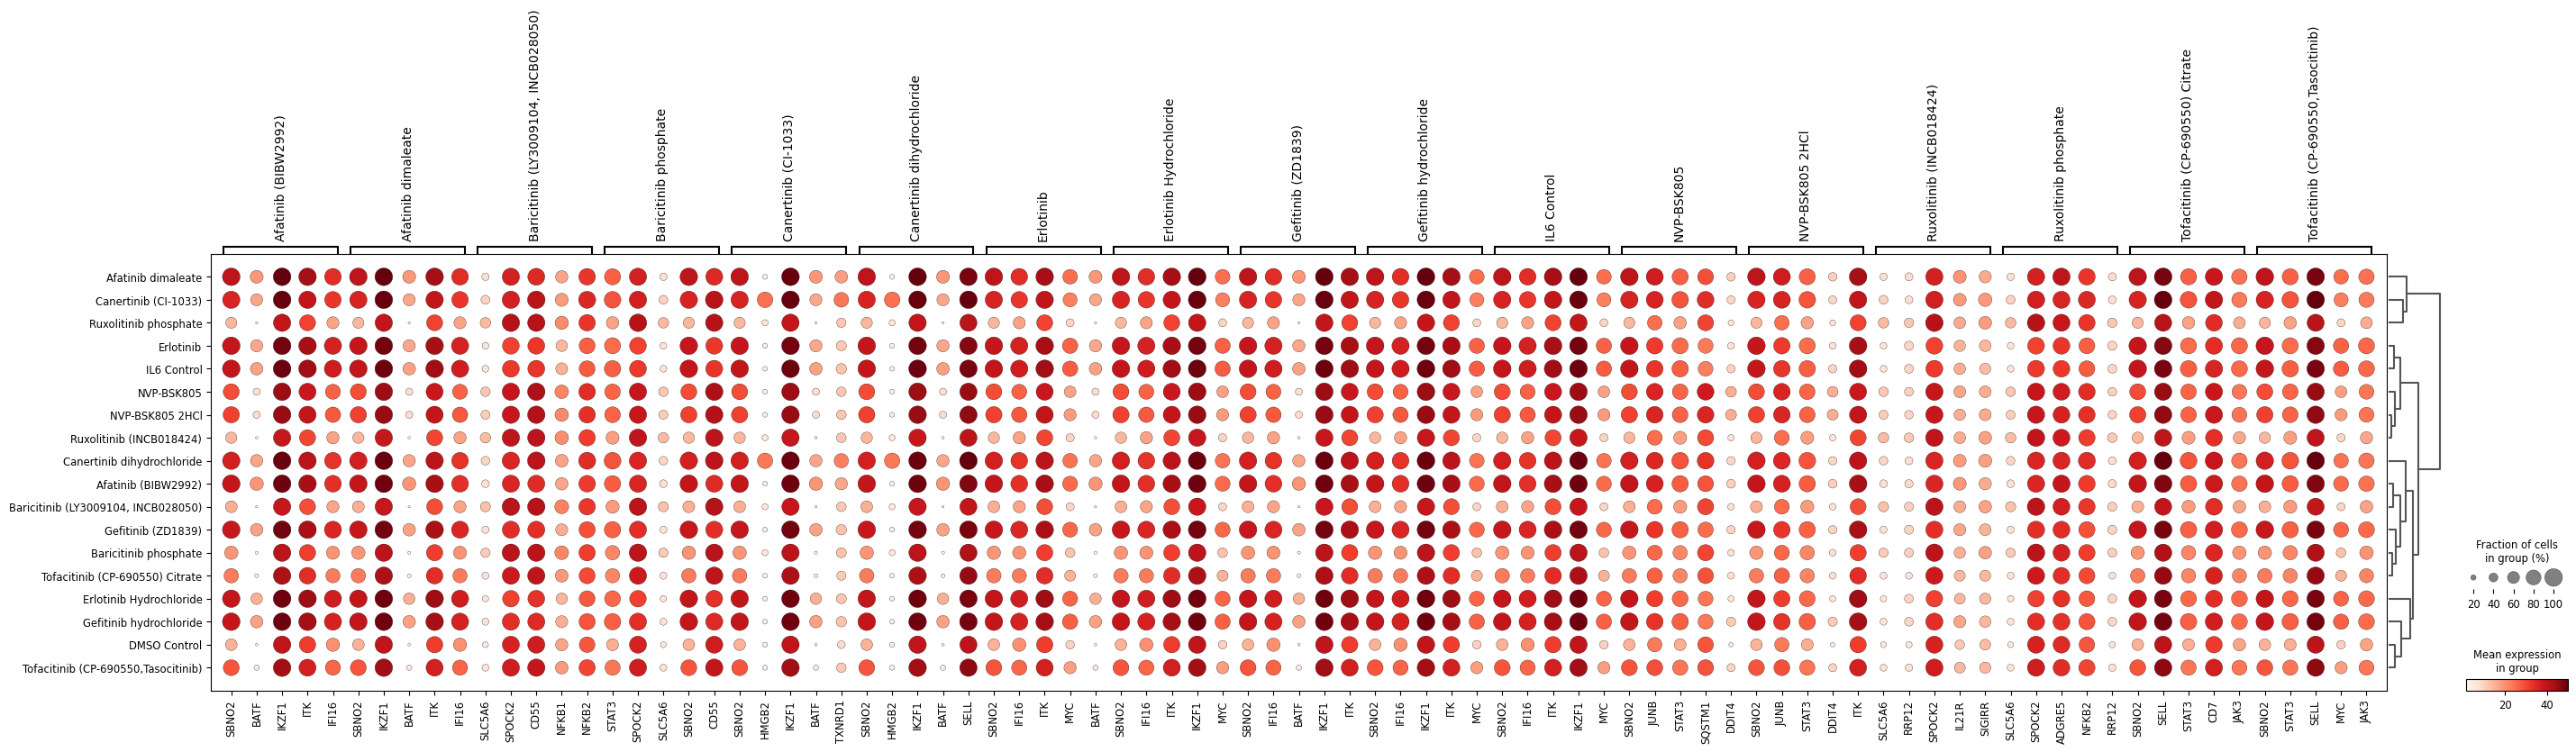

CD4 Effector Memory
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


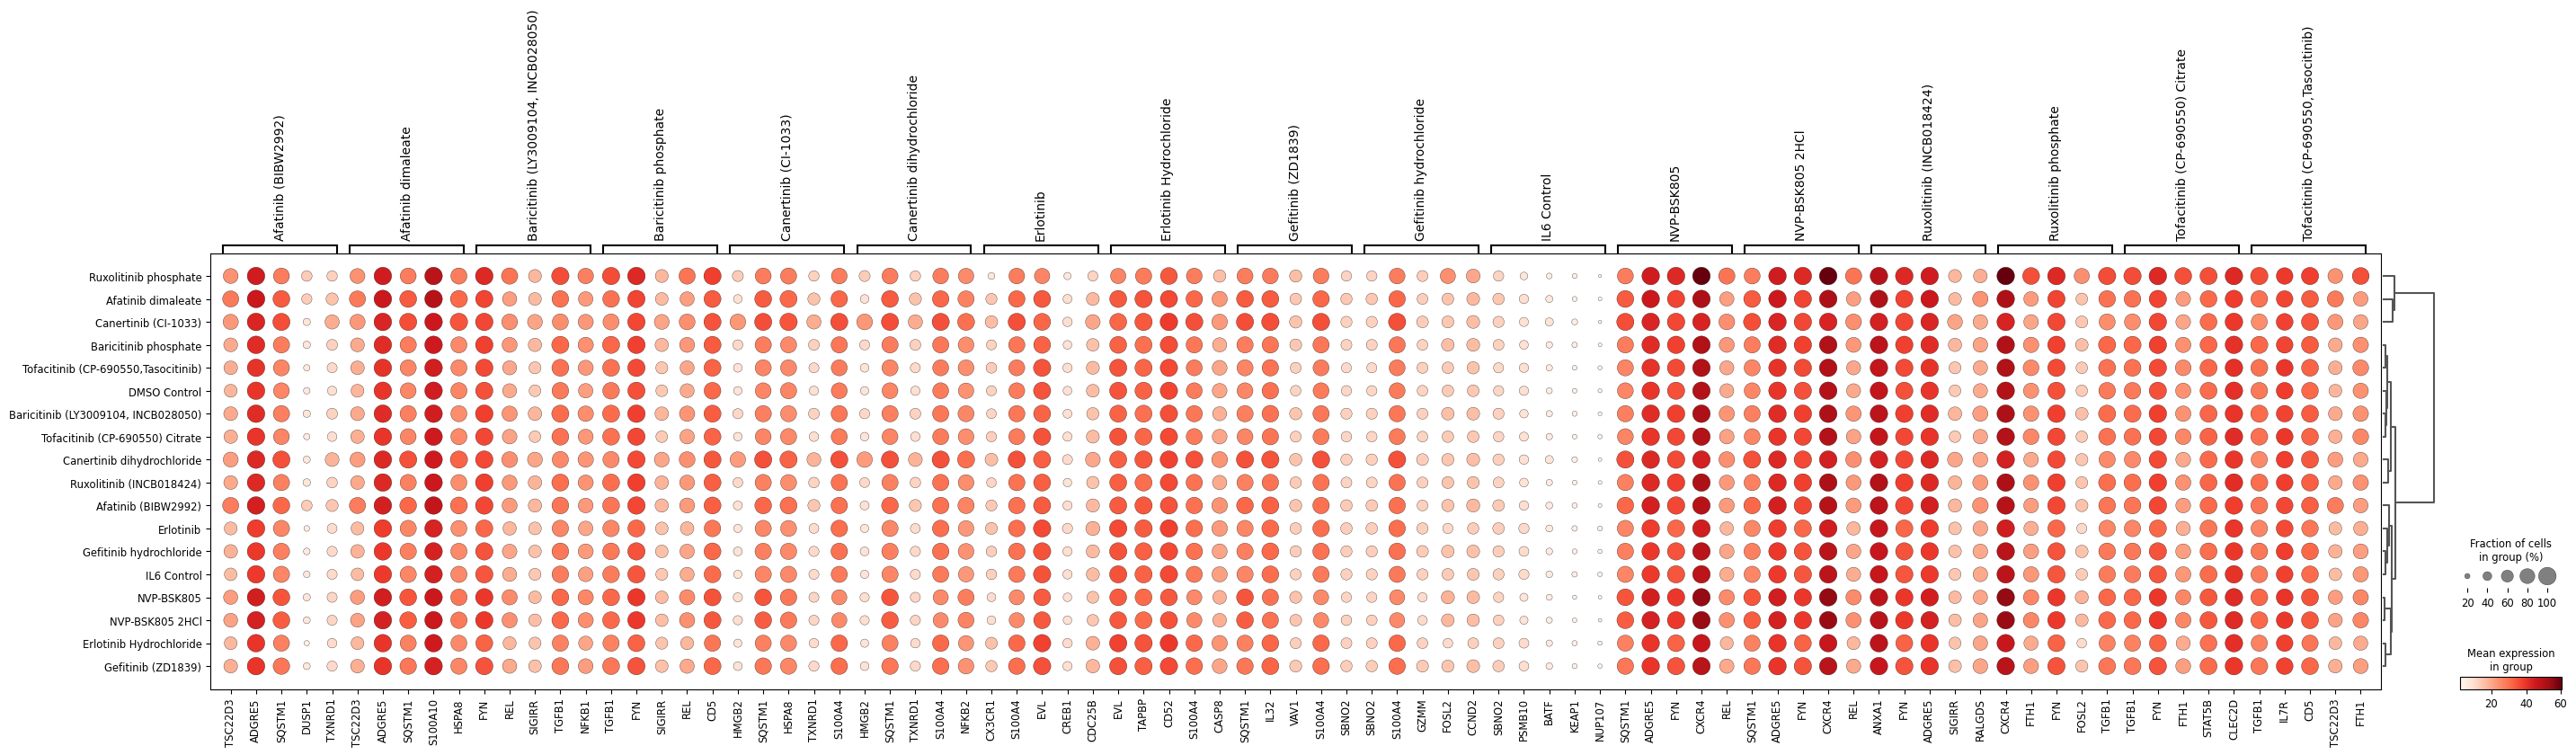

MAIT
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


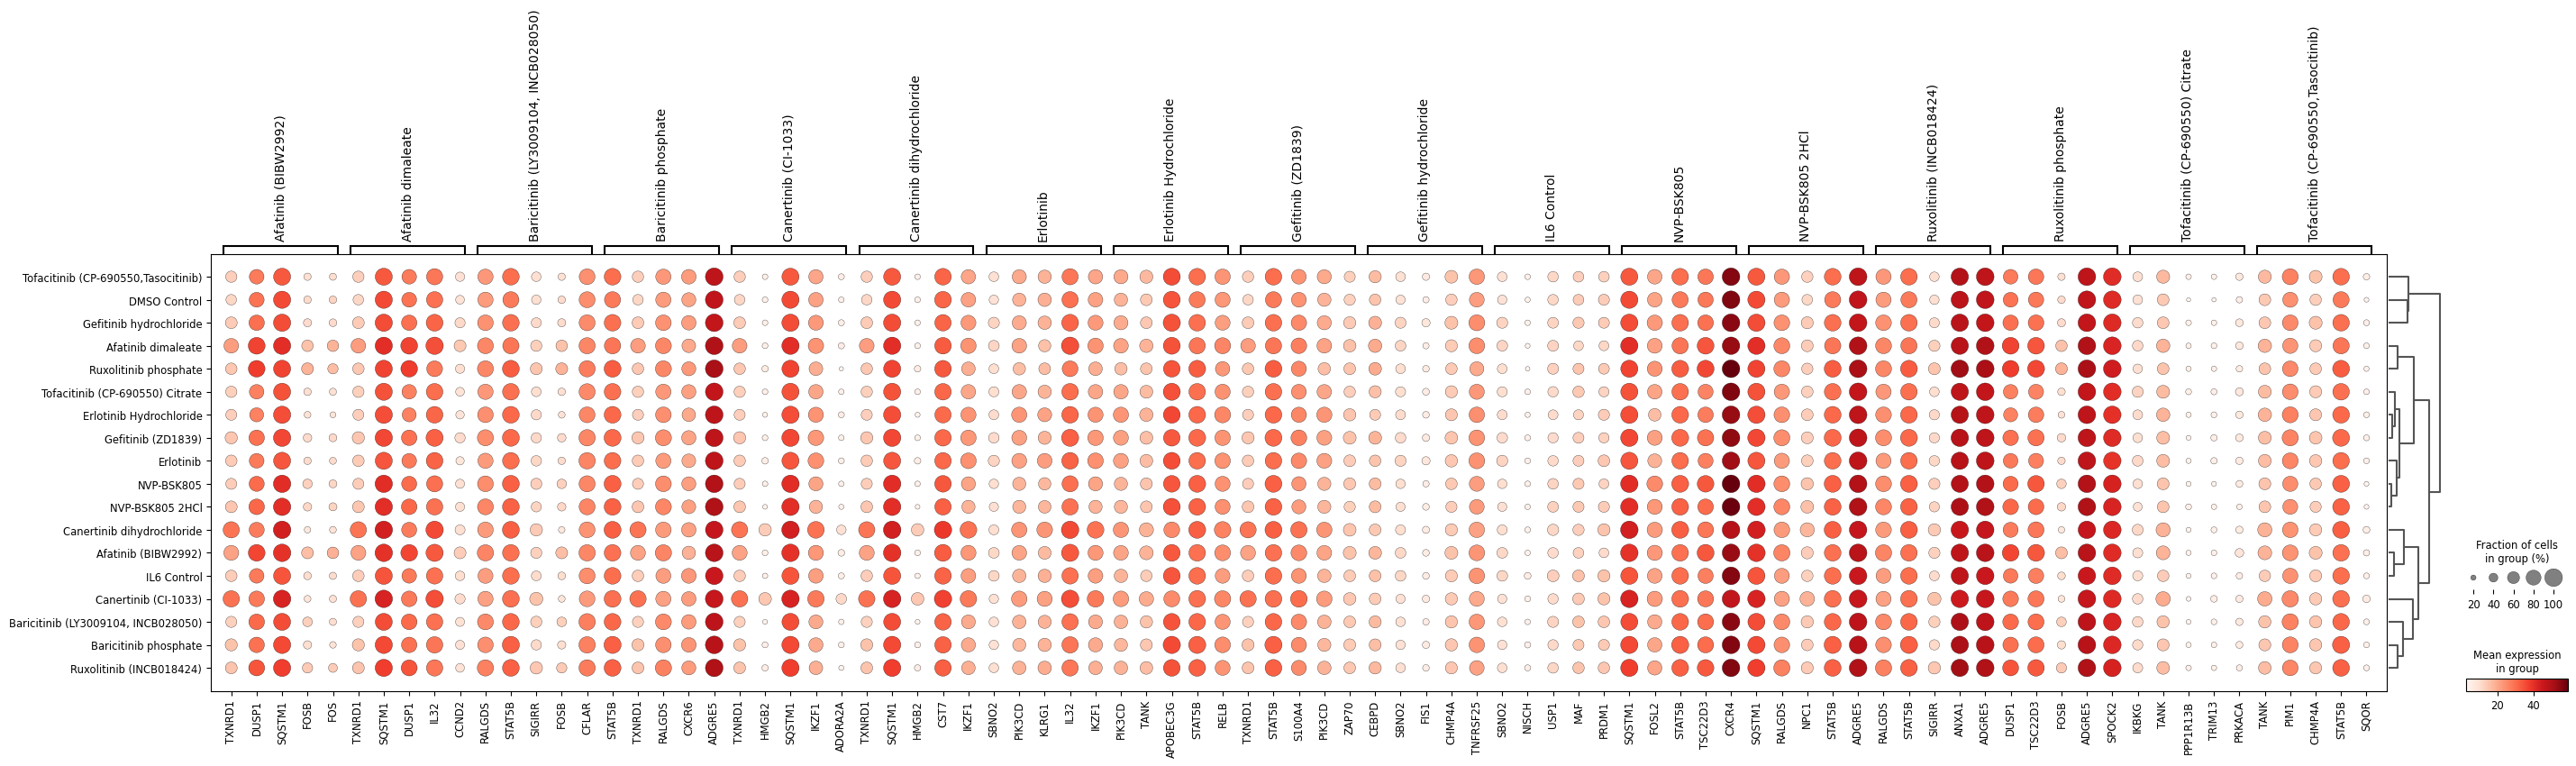

Treg
categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.


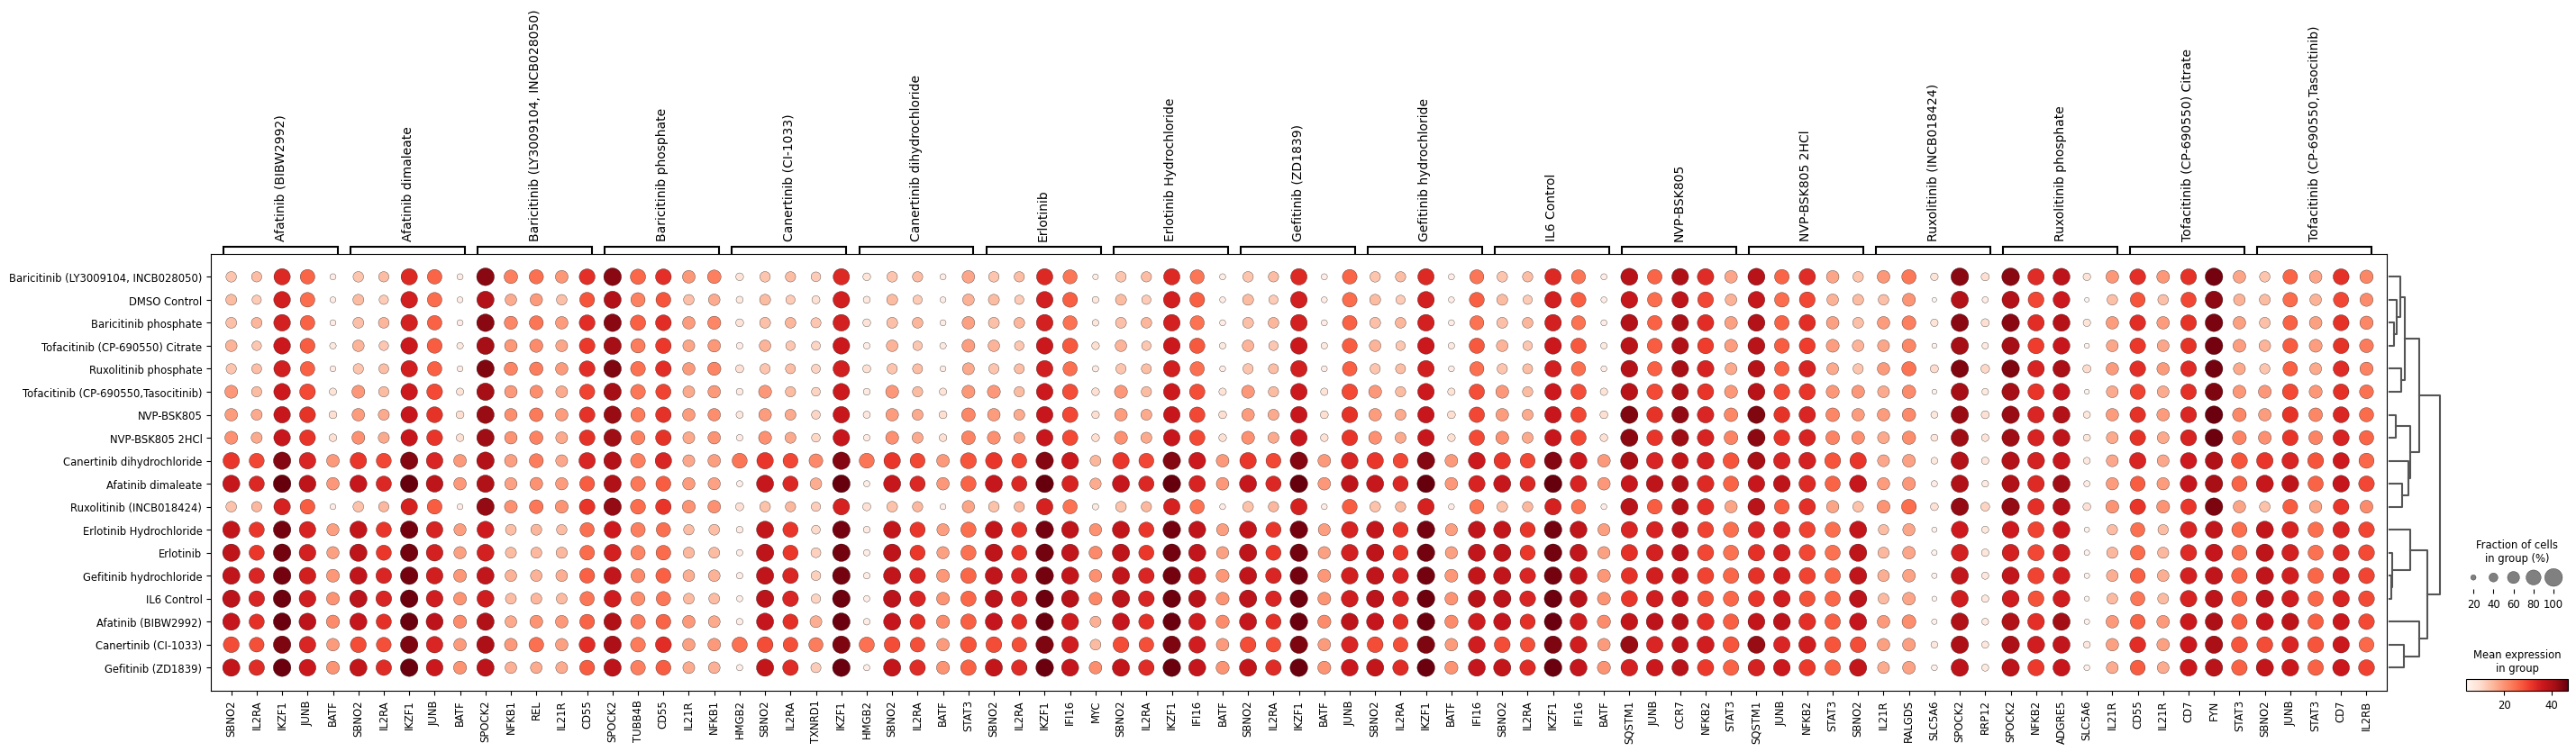

In [23]:
for cell_type, subset_cell in subsets_cells.items():    
    print(cell_type)
    sc.pl.rank_genes_groups_dotplot(subset_cell, groupby="drug_name", n_genes=5)

# Starting Gene Set Enrichment Analysis using GSEAPY

**Note: We are looking at *each* drug (`drug_name`) vs. DMSO control (the reference) for *each* cell type (AIFI_L2)**.

## Extract DEG results into ranked genes first

We need a table with all DEGs and their log foldchanges. However, many lowly expressed genes will have high foldchanges and just contribue noise, so also filter for expression in enough cells.

`sc.get.rank_genes_groups_df(subset_cell, group=drug)` returns a nice table with `names` (DEG (gene) names), `scores`, `logfoldchanges`, `pvals_adj`, etc...

For each drug vs. DMSO, extract a ranked gene list with GENE and RANK_METRIC??

In [38]:
for cell_type, subset_cell in subsets_cells.items():

    # adapted from tutorial linked above: calculate_qc_metrics will calculate number of cells per gene
    sc.pp.calculate_qc_metrics(subset_cell, percent_top=None, log1p=False, inplace=True)

    # list of drug "groups"
    deg = subset_cell.uns["rank_genes_groups"]
    drugs = deg["names"].dtype.names

    for drug in drugs:
        if drug == "DMSO Control":
            continue # skip reference condition

        # adapted from tutorial linked above: extract ranked genes (names + logFC)
        gene_rank = sc.get.rank_genes_groups_df(
            subset_cell,
            group = drug,
            key= 'rank_genes_groups')[['names','logfoldchanges']]
    
        # adapted from tutorial above: filter for genes expressed in at least 30 cells
        gene_rank = gene_rank[gene_rank["names"].isin(
            subset_cell.var_names[subset_cell.var.n_cells_by_counts > 30]
        )]
        
        # Need to play around with this!! # Run prerank GSEA directly with gp.prerank()
        pre_res = gp.prerank(
            rnk = gene_rank,
            gene_sets = "KEGG_2021_Human", # Could also download gene sets from: Msigdb hallmark gene sets, Reactome, etc...
            # tutorial in GSEAPY documentation
            outdir = None
        )

In [30]:
pre_res.res2d.head(5)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Choline metabolism in cancer,0.872824,1.878962,0.011561,0.933592,0.498,1/26,0.48%,PDGFA
1,prerank,Melanogenesis,0.862915,1.838084,0.059305,0.824527,0.675,1/20,0.07%,FZD7
2,prerank,Cell adhesion molecules,-0.744631,-1.824976,0.080412,1.0,0.756,4/37,4.04%,PDCD1LG2;ICAM1;PECAM1;CD8A
3,prerank,Gap junction,0.849356,1.818292,0.108652,0.693408,0.729,1/17,0.48%,PDGFA
4,prerank,Signaling pathways regulating pluripotency of ...,0.797878,1.803511,0.031365,0.606944,0.764,1/39,0.07%,FZD7


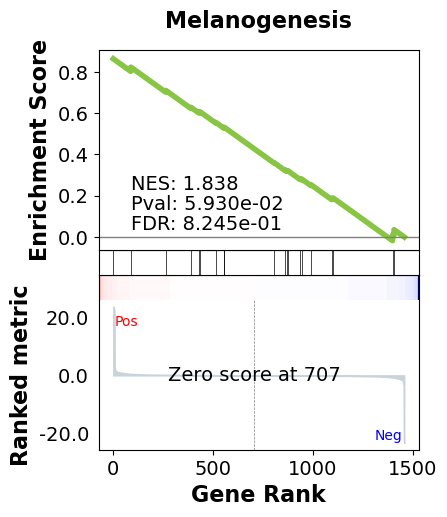

In [31]:
## easy way
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=terms[1]) # v1.0.5
# to make more control on the plot, use
# from gseapy import gseaplot
# gseaplot(rank_metric=pre_res.ranking, term=terms[0], ofname='your.plot.pdf', **pre_res.results[terms[0]])

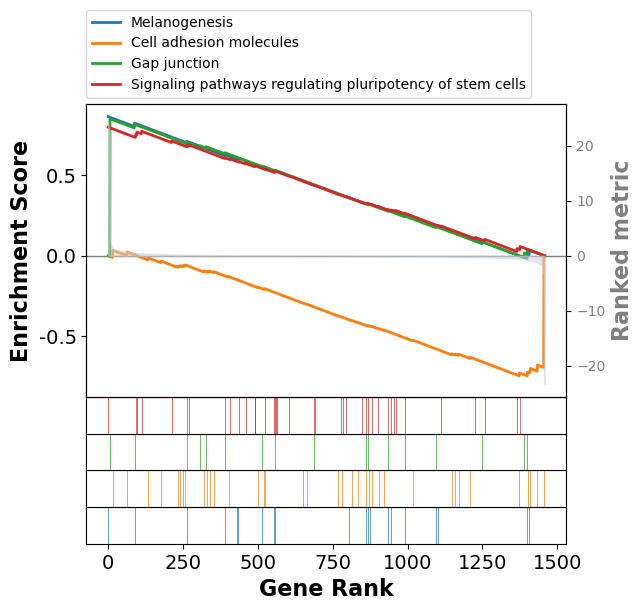

In [32]:
axs = pre_res.plot(terms=terms[1:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )
# or use this to have more control on the plot
# from gseapy import gseaplot2
# terms = pre_res.res2d.Term[1:5]
# hits = [pre_res.results[t]['hits'] for t in terms]
# runes = [pre_res.results[t]['RES'] for t in terms]
# fig = gseaplot2(terms=terms, ress=runes, hits=hits,
#               rank_metric=gs_res.ranking,
#               legend_kws={'loc': (1.2, 0)}, # set the legend loc
#               figsize=(4,5)) # rank_metric=pre_res.ranking

In [35]:
from gseapy import dotplot

In [39]:
# to save your figure, make sure that ``ofname`` is not None
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG_2016',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,5), cutoff=0.25, show_ring=False)

ValueError: Warning: No enrich terms when cutoff = 0.25